# Model Training Script
Lindsay Fitzpatrick
ljob@umich.edu
12/18/2024

This script reads in CFSR data from 1979 - 2010 and trains machine learning models to target CNBS from L2SWBM across the 5 Great Lakes simultaeously.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import sys
import os

In [2]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader

## User Input

In [3]:
# This is the directory where you cloned the repo
local_path = '/Users/ljob/Desktop/'

input_dir = local_path + 'cnbs-predictor/data/'

## Begin Script

In [4]:
## Read in PCP data from CFSR [mm]
pcp_data = pd.read_csv(input_dir+'cfsr/CFSR_APCP_Basin_Avgs.csv',sep=',')

## Read in EVAP data from CFSR [mm]
evap_data = pd.read_csv(input_dir+'cfsr/CFSR_EVAP_Basin_Avgs.csv',sep=',')

## Read in TMP data from CFSR [K]
tmp_data = pd.read_csv(input_dir+'cfsr/CFSR_TMP_Basin_Avgs.csv',sep=',')

## Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

### 4. Include Seasonality
- Extract the calendar month from the datetime index.  
- Convert the month into **one-hot encoded categorical variables** (`month_1` through `month_12`).

### 5. Reorder Features
- Columns are reorganized to ensure consistent ordering:  
  1. Month indicators (`month_1` … `month_12`)  
  2. Basin-specific variables for precipitation, evaporation, and air temperature across all lead times (`mo0` … `mo9`).

### 6. Include Lake Surface Temperature (GLSEA SST)
- Load Great Lakes Surface Environmental Analysis (GLSEA) SST data (`oisst_sst_1981-2024.csv`) in Kelvin.  
- Merge SST with the reorganized predictor matrix to produce the final feature dataset (`X_merged`).

### 7. Feature Table Example

| Feature Category | Example Feature Names (Lead Times 0–9) |
|-----------------|----------------------------------------|
| SST | `superior_sst` |
| Month Indicators | `month_1, month_2, ..., month_12` |
| Precipitation (Lake) | `superior_lake_precipitation_mo0, ..., mo9`|
| Precipitation (Land) | `superior_land_precipitation_mo0, ..., mo9` |
| Evaporation (Lake) | `superior_lake_evaporation_mo0, ..., mo9` |
| Evaporation (Land) | `superior_land_evaporation_mo0, ..., mo9` |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0, ..., mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0, ..., mo9` |

In [5]:
# Set the index by date
pcp_data['date'] = pd.to_datetime(pcp_data[['year', 'month']].assign(day=1))

In [6]:
# Features
X = pd.DataFrame({
    'superior_lake_precipitation':  pcp_data['sup_lake'],
    'michigan-huron_lake_precipitation': pcp_data['mih_lake'],
    'erie_lake_precipitation': pcp_data['eri_lake'],
    'ontario_lake_precipitation': pcp_data['ont_lake'],
    'superior_land_precipitation': pcp_data['sup_land'],
    'michigan-huron_land_precipitation': pcp_data['mih_land'],
    'erie_land_precipitation': pcp_data['eri_land'],
    'ontario_land_precipitation': pcp_data['ont_land'],
    'superior_lake_evaporation': evap_data['sup_lake'],
    'michigan-huron_lake_evaporation': evap_data['mih_lake'],
    'erie_lake_evaporation': evap_data['eri_lake'],
    'ontario_lake_evaporation': evap_data['ont_lake'],
    'superior_land_evaporation': evap_data['sup_land'],
    'michigan-huron_land_evaporation': evap_data['mih_land'],
    'erie_land_evaporation': evap_data['eri_land'],
    'ontario_land_evaporation': evap_data['ont_land'],
    'superior_lake_air_temperature': tmp_data['sup_lake'],
    'michigan-huron_lake_air_temperature': tmp_data['mih_lake'],
    'erie_lake_air_temperature': tmp_data['eri_lake'],
    'ontario_lake_air_temperature': tmp_data['ont_lake'],
    'superior_land_air_temperature': tmp_data['sup_land'],
    'michigan-huron_land_air_temperature': tmp_data['mih_land'],
    'erie_land_air_temperature': tmp_data['eri_land'],
    'ontario_land_air_temperature': tmp_data['ont_land']
})

# Set the index by date
X.set_index(pd.to_datetime(pcp_data[['year', 'month']].assign(day=1)), inplace=True)

# Shift the features to create lead times from 0 to 9 months
X_shifted = CFSTransformer(X).shift_variables(lag=0, lead=10)

#Add a month variable to the shifted DataFrame
X_shifted = pd.concat([X_shifted, pd.DataFrame({'month': X_shifted.index.month,}, index=X_shifted.index)], axis=1)
X_shifted = pd.get_dummies(X_shifted, columns=['month'], prefix='month')

feature_column_order = (
    #[f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

# Reorder the columns to match the specified order
X_reorg = X_shifted.reindex(columns=feature_column_order)

# Load in GLSEA SST data and merge with features
dataloader = DataLoader()
X_merged = X_reorg.copy()

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [7]:
# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [8]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_merged.align(targets_reorg, join='inner', axis=0)
print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 240
Number of Targets: 192


## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [9]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1981-09-01'
train_end_date = '2005-12-01'

# Testing dataset
val_start_date = '2006-01-01'
val_end_date = '2010-03-01'

X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test =aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

In [10]:
lake_data = {}
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
month_cols = [f'month_{i}' for i in range(1, 13)]

for lake in lakes:
    target_cols = [col for col in aligned_y.columns if col.startswith(f'{lake}_target')]
    lake_feature_cols = [col for col in X_train.columns if col.startswith(lake)]
    #feature_cols = month_cols + lake_feature_cols

    lake_data[lake] = {
        'X_train': X_train[lake_feature_cols],
        'y_train': y_train[target_cols],
        'X_test': X_test[lake_feature_cols],
        'y_test': y_test[target_cols]
    }

print(lake_data['erie']['y_train'].columns)

Index(['erie_target_precipitation_mo0', 'erie_target_precipitation_mo1',
       'erie_target_precipitation_mo2', 'erie_target_precipitation_mo3',
       'erie_target_precipitation_mo4', 'erie_target_precipitation_mo5',
       'erie_target_precipitation_mo6', 'erie_target_precipitation_mo7',
       'erie_target_precipitation_mo8', 'erie_target_precipitation_mo9',
       'erie_target_precipitation_mo10', 'erie_target_precipitation_mo11',
       'erie_target_evaporation_mo0', 'erie_target_evaporation_mo1',
       'erie_target_evaporation_mo2', 'erie_target_evaporation_mo3',
       'erie_target_evaporation_mo4', 'erie_target_evaporation_mo5',
       'erie_target_evaporation_mo6', 'erie_target_evaporation_mo7',
       'erie_target_evaporation_mo8', 'erie_target_evaporation_mo9',
       'erie_target_evaporation_mo10', 'erie_target_evaporation_mo11',
       'erie_target_runoff_mo0', 'erie_target_runoff_mo1',
       'erie_target_runoff_mo2', 'erie_target_runoff_mo3',
       'erie_target_runoff

In [11]:
from sklearn.preprocessing import StandardScaler
import joblib

lake_scalers = {}

for lake, data in lake_data.items():
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    # Fit on training data for this lake
    X_train_scaled = x_scaler.fit_transform(data['X_train'])
    X_test_scaled = x_scaler.transform(data['X_test'])
    
    y_train_scaled = y_scaler.fit_transform(data['y_train'])
    y_test_scaled = y_scaler.transform(data['y_test'])
    
    # Replace original data with scaled arrays (or keep both if you want)
    lake_data[lake]['X_train_scaled'] = X_train_scaled
    lake_data[lake]['X_test_scaled'] = X_test_scaled
    lake_data[lake]['y_train_scaled'] = y_train_scaled
    lake_data[lake]['y_test_scaled'] = y_test_scaled
    
    # Save scalers for future predictions
    joblib.dump(x_scaler, f'{input_dir}input/scalers/{lake}_x_scaler.joblib')
    joblib.dump(y_scaler, f'{input_dir}input/scalers/{lake}_y_scaler.joblib')
    
    # Optionally, store scalers in memory for quick access
    lake_scalers[lake] = {'x_scaler': x_scaler, 'y_scaler': y_scaler}
    
    print(f"Scaled features and targets for {lake}")


Scaled features and targets for superior
Scaled features and targets for michigan-huron
Scaled features and targets for erie
Scaled features and targets for ontario


## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

In [12]:

# Define the kernel
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

lake_gp_results = {}

for lake, data in lake_data.items():
    print(f"\nTraining Gaussian Process for {lake}...")
    
    X_train_scaled = data['X_train_scaled']
    X_test_scaled = data['X_test_scaled']
    y_train_scaled = data['y_train_scaled']
    y_test_scaled = data['y_test_scaled']
    
    # Initialize the GP regressor
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, 
                                   n_restarts_optimizer=10, random_state=42)
    
    # Fit the model
    gpr.fit(X_train_scaled, y_train_scaled)
    
    # Save the trained model
    joblib.dump(gpr, f'{input_dir}input/models/GP_trained_model_{lake}.joblib')
    
    # Make predictions
    y_pred, sigma = gpr.predict(X_test_scaled, return_std=True)
    
    # Evaluate
    r2 = r2_score(y_test_scaled, y_pred)
    print(f"{lake} R² Score: {r2:.4f}")
    
    # Store results and model info
    lake_gp_results[lake] = {
        'model': gpr,
        'r2': r2,
        'y_pred': y_pred,
        'sigma': sigma,
        'X_test_scaled': X_test_scaled,
        'y_test_scaled': y_test_scaled
    }
    
    # Optional: print optimized kernel
    print("Optimized Kernel:", gpr.kernel_)
    print("Kernel Hyperparameters:", gpr.kernel_.theta)


Training Gaussian Process for superior...


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


superior R² Score: 0.7823
Optimized Kernel: 2.47**2 * Matern(length_scale=35.1, nu=1.5) * RationalQuadratic(alpha=0.000275, length_scale=1e-05)
Kernel Hyperparameters: [  1.8121123    3.5584378   -8.1992266  -11.51292546]

Training Gaussian Process for michigan-huron...
michigan-huron R² Score: 0.8069
Optimized Kernel: 4.42**2 * Matern(length_scale=61.7, nu=1.5) * RationalQuadratic(alpha=0.000636, length_scale=10.4)
Kernel Hyperparameters: [ 2.97199525  4.12192754 -7.36101806  2.34566528]

Training Gaussian Process for erie...


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


erie R² Score: 0.7675
Optimized Kernel: 2.86**2 * Matern(length_scale=39.8, nu=1.5) * RationalQuadratic(alpha=0.000339, length_scale=1e-05)
Kernel Hyperparameters: [  2.10082119   3.6847155   -7.99009806 -11.51292546]

Training Gaussian Process for ontario...
ontario R² Score: 0.7421
Optimized Kernel: 2.52**2 * Matern(length_scale=33.1, nu=1.5) * RationalQuadratic(alpha=0.000296, length_scale=1e-05)
Kernel Hyperparameters: [  1.85130199   3.50023294  -8.12623017 -11.51292546]


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [13]:
#import xgboost as xgb

lake_xgb_results = {}

for lake, data in lake_data.items():
    print(f"\nTraining XGBoost for {lake}...")
    
    X_train_scaled = data['X_train_scaled']
    X_test_scaled = data['X_test_scaled']
    y_train_scaled = data['y_train_scaled']
    y_test_scaled = data['y_test_scaled']
    
    # Initialize XGBoost Regressor
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    )
    
    # Fit the model
    xgb_model.fit(X_train_scaled, y_train_scaled)
    
    # Save the trained model
    joblib.dump(xgb_model, f'{input_dir}input/models/XGB_trained_model_{lake}.joblib')
    
    # Predict
    y_pred = xgb_model.predict(X_test_scaled)
    
    # Evaluate
    r2 = r2_score(y_test_scaled, y_pred)
    print(f"{lake} R² Score: {r2:.4f}")
    
    # Store results
    lake_xgb_results[lake] = {
        'model': xgb_model,
        'r2': r2,
        'y_pred': y_pred,
        'X_test_scaled': X_test_scaled,
        'y_test_scaled': y_test_scaled
    }



Training XGBoost for superior...
superior R² Score: 0.6840

Training XGBoost for michigan-huron...
michigan-huron R² Score: 0.7627

Training XGBoost for erie...
erie R² Score: 0.7325

Training XGBoost for ontario...
ontario R² Score: 0.7132


In [14]:
## Random Forest Regressor Model:

lake_rf_results = {}

for lake, data in lake_data.items():
    print(f"\nTraining Random Forest for {lake}...")
    
    X_train_scaled = data['X_train_scaled']
    X_test_scaled = data['X_test_scaled']
    y_train_scaled = data['y_train_scaled']
    y_test_scaled = data['y_test_scaled']
    
    # Initialize Random Forest Regressor
    rfr_model = skRFR(random_state=42)
    
    # Fit the model
    trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)
    
    # Save the trained model
    joblib.dump(trained_RFR, f'{input_dir}input/models/RF_trained_model_{lake}.joblib')
    
    # Predict
    y_pred = trained_RFR.predict(X_test_scaled)
    
    # Evaluate
    r2 = r2_score(y_test_scaled, y_pred)
    print(f"{lake} R² Score: {r2:.4f}")
    
    # Store results
    lake_rf_results[lake] = {
        'model': trained_RFR,
        'r2': r2,
        'y_pred': y_pred,
        'X_test_scaled': X_test_scaled,
        'y_test_scaled': y_test_scaled
    }


Training Random Forest for superior...
superior R² Score: 0.5792

Training Random Forest for michigan-huron...
michigan-huron R² Score: 0.5684

Training Random Forest for erie...
erie R² Score: 0.5209

Training Random Forest for ontario...
ontario R² Score: 0.5249



Training Neural Network for superior...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0915 - mae: 0.8406 - val_loss: 0.8145 - val_mae: 0.7498
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8764 - mae: 0.7450 - val_loss: 0.6931 - val_mae: 0.6815
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7467 - mae: 0.6724 - val_loss: 0.5944 - val_mae: 0.6152
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6339 - mae: 0.6051 - val_loss: 0.5029 - val_mae: 0.5538
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5351 - mae: 0.5467 - val_loss: 0.4348 - val_mae: 0.5088
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4625 - mae: 0.5046 - val_loss: 0.3847 - val_mae: 0.4751
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4098 - mae: 0.4728 - val_loss: 0.3464 - val_mae: 0.4509
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3749 - mae: 0.4505 - val_loss: 0.3235 - val_mae: 0.4327
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

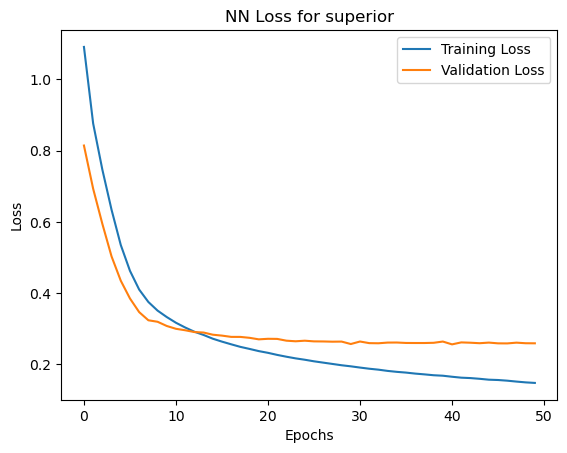

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
superior R² Score: 0.7139

Training Neural Network for michigan-huron...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0848 - mae: 0.8399 - val_loss: 0.9766 - val_mae: 0.8015
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8579 - mae: 0.7409 - val_loss: 0.8398 - val_mae: 0.7393
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7522 - mae: 0.6859 - val_loss: 0.7372 - val_mae: 0.6870
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6611 - mae: 0.6339 - val_loss: 0.6415 - val_mae: 0.6320
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5817 - mae: 0.5864 - val_loss: 0.5625 - val_mae: 0.5851
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5170 - mae: 0.5474 - val_loss: 0.5022 - val_mae: 0.5491
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4701 - mae: 0.5202 - val_loss: 0.4633 - val_mae: 0.5259
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4346 - mae: 0.5004 - val_loss: 0

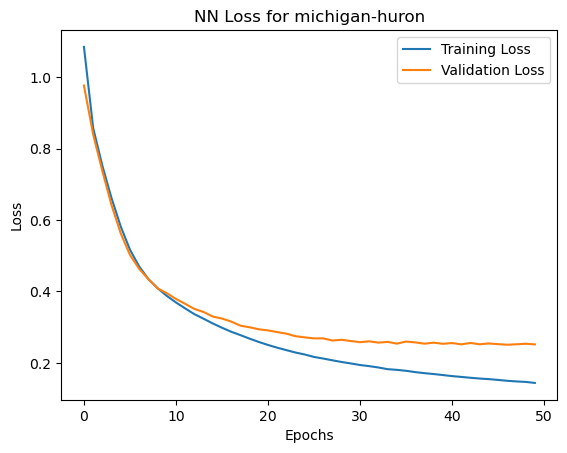

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
michigan-huron R² Score: 0.7203

Training Neural Network for erie...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1831 - mae: 0.8836 - val_loss: 0.8958 - val_mae: 0.7794
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9339 - mae: 0.7823 - val_loss: 0.7767 - val_mae: 0.7208
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8328 - mae: 0.7299 - val_loss: 0.6878 - val_mae: 0.6693
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7407 - mae: 0.6777 - val_loss: 0.6017 - val_mae: 0.6141
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6562 - mae: 0.6268 - val_loss: 0.5257 - val_mae: 0.5657
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5812 - mae: 0.5847 - val_loss: 0.4648 - val_mae: 0.5281
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5212 - mae: 0.5488 - val_loss: 0.4178 - val_mae: 0.4967
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4758 - mae: 0.5192 - val_loss: 0.391

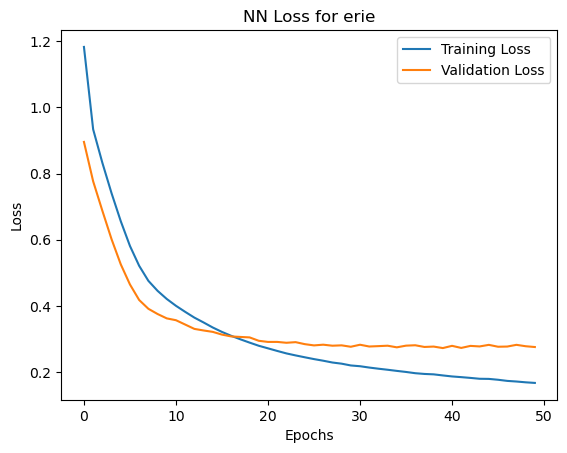

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x31a492f20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
erie R² Score: 0.7076

Training Neural Network for ontario...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1288 - mae: 0.8545 - val_loss: 0.9051 - val_mae: 0.7764
Epoch 2/50
8/8 ━━━━━━━━━━━━━━

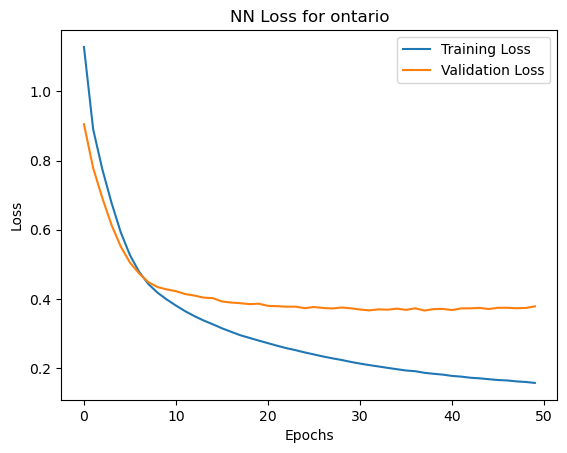

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
ontario R² Score: 0.6458


In [15]:
## Neural Network ##

lake_nn_results = {}

for lake, data in lake_data.items():
    print(f"\nTraining Neural Network for {lake}...")
    
    X_train_scaled = data['X_train_scaled']
    X_test_scaled = data['X_test_scaled']
    y_train_scaled = data['y_train_scaled']
    y_test_scaled = data['y_test_scaled']
    
    # Define the model architecture
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(y_train_scaled.shape[1])  # Output layer
    ])
    
    # Compile the model
    nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Fit the model
    history = nn_model.fit(
        X_train_scaled, y_train_scaled,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    
    # Optional: plot training/validation loss
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'NN Loss for {lake}')
    plt.legend()
    plt.show()
    
    # Save the model
    joblib.dump(nn_model, f'{input_dir}input/models/NN_trained_model_{lake}.joblib')
    
    # Predict
    y_pred = nn_model.predict(X_test_scaled)
    
    # Evaluate R²
    r2 = r2_score(y_test_scaled, y_pred)
    print(f"{lake} R² Score: {r2:.4f}")
    
    # Store results
    lake_nn_results[lake] = {
        'model': nn_model,
        'r2': r2,
        'y_pred': y_pred,
        'X_test_scaled': X_test_scaled,
        'y_test_scaled': y_test_scaled,
        'history': history
    }
